In [15]:
import os
import sys
import json
import re
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import joblib

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Establish project root directory
ROOT_DIR = Path.cwd()
while ROOT_DIR != ROOT_DIR.parent and not (ROOT_DIR / "pyproject.toml").exists() and not (ROOT_DIR / ".git").exists():
    ROOT_DIR = ROOT_DIR.parent

# Define file paths
CLS_CSV = ROOT_DIR / "data" / "processed" / "classification_dataset" / "classification_dataset.csv"
AUG_JSONL = ROOT_DIR / "data" / "summarizerdata" / "final_dataset_augmented.jsonl"
GOLD_PATH = ROOT_DIR / "submission" / "week_4" / "ner_gold.jsonl"
MODELS_DIR = ROOT_DIR / "models"
WEEK5_DIR = ROOT_DIR / "submission" / "week_5"

# Add WEEK5_DIR to sys.path to import integrated_pipeline
sys.path.insert(0, str(WEEK5_DIR))
import importlib
import integrated_pipeline
importlib.reload(integrated_pipeline)

from integrated_pipeline import (
    NoticeClassifier, NoticeEntityExtractor, 
    PersonaSummarizer, IntegratedNoticePipeline
)

print("Loading saved Stage 1, Stage 2, and Stage 3 models...")

STAGE1_DIR = MODELS_DIR / "week5" / "stage1"
cat_vec = joblib.load(STAGE1_DIR / "cat_vectorizer.joblib")
cat_model = joblib.load(STAGE1_DIR / "cat_model.joblib")
aud_vec = joblib.load(STAGE1_DIR / "aud_vectorizer.joblib")
aud_model = joblib.load(STAGE1_DIR / "aud_model.joblib")
mlb = joblib.load(STAGE1_DIR / "mlb.joblib")

with open(STAGE1_DIR / "stage1_config.json") as f:
    cfg = json.load(f)

classifier = NoticeClassifier(cat_vec, cat_model, aud_vec, aud_model, mlb, cfg["cat_title_repeat"], cfg["aud_title_repeat"], cfg["thresholds"])
extractor = NoticeEntityExtractor(model_name="dslim/bert-base-NER")
summarizer = PersonaSummarizer(model_dir=MODELS_DIR / "bart_sysB_best")

pipeline = IntegratedNoticePipeline(classifier, extractor, summarizer)
print("Pipeline loaded and ready for live execution!")

Loading saved Stage 1, Stage 2, and Stage 3 models...
Pipeline loaded and ready for live execution!


In [16]:
# import matplotlib.pyplot as plt
# from sklearn.metrics import (
#     accuracy_score, f1_score, classification_report, 
#     confusion_matrix, ConfusionMatrixDisplay
# )

# # Load Classification Test Set
# df = pd.read_csv(CLS_CSV)
# df["document_id"] = df["document_id"].astype(str)
# df["split"] = df["split"].replace({"validation": "val"})
# test_df = df[df["split"] == "test"].copy()
# test_df["cleaned_text"] = test_df["cleaned_text"].fillna("")

# def parse_labels(series):
#     return [json.loads(x) if isinstance(x, str) and x.startswith("[") else [x] for x in series]

# # Transform Multi-Label Audience using loaded mlb
# Y_aud_true = mlb.transform(parse_labels(test_df["audience_labels"]))
# y_cat_true = test_df["category"].values

# # Execute Predictions
# preds = [classifier.predict(t) for t in test_df["cleaned_text"]]
# y_cat_pred = np.array([p["category"] for p in preds])
# Y_aud_pred = np.array([[int(c in p["audience"]) for c in mlb.classes_] for p in preds])

# # Compute Metrics
# cat_acc = accuracy_score(y_cat_true, y_cat_pred)
# cat_macro_f1 = f1_score(y_cat_true, y_cat_pred, average="macro", zero_division=0)
# aud_micro_f1 = f1_score(Y_aud_true, Y_aud_pred, average="micro", zero_division=0)

# print("=== STAGE 1 CLASSIFICATION METRICS ===")
# print(f"Category Accuracy : {cat_acc:.4f} (Baseline: 0.9583)")
# print(f"Category Macro-F1 : {cat_macro_f1:.4f} (Baseline: 0.9645)")
# print(f"Audience Micro-F1 : {aud_micro_f1:.4f} (Baseline: 0.9375)")

# # Plot Confusion Matrix
# fig, ax = plt.subplots(figsize=(6, 5))
# labels = list(classifier.cat_model.classes_)
# ConfusionMatrixDisplay(confusion_matrix(y_cat_true, y_cat_pred, labels=labels), display_labels=labels).plot(
#     ax=ax, cmap="Blues", xticks_rotation=45
# )
# ax.set_title("Stage 1 Category Confusion Matrix (Week 5 Test Set)")
# plt.tight_layout()
# plt.savefig(WEEK5_DIR / "stage1_confusion_matrix.png", dpi=120)
# plt.show()

=== STAGE 1 CLASSIFICATION (n_test = 24; 1 doc ≈ 4.2% accuracy shift) ===


,plain_baseline,integrated_stage1,delta
category_accuracy,0.9583,0.9167,-0.0416
category_macro_f1,0.9645,0.8764,-0.0881
audience_micro_f1,0.9375,0.8852,-0.0523
audience_macro_f1,0.8786,0.8946,0.0160



--- Category Classification Report ---
              precision    recall  f1-score   support

    academic       1.00      0.50      0.67         2
   admission       1.00      0.93      0.97        15
 examination       1.00      1.00      1.00         2
     general       0.60      1.00      0.75         3
      hostel       1.00      1.00      1.00         2

    accuracy                           0.92        24
   macro avg       0.92      0.89      0.88        24
weighted avg       0.95      0.92      0.92        24



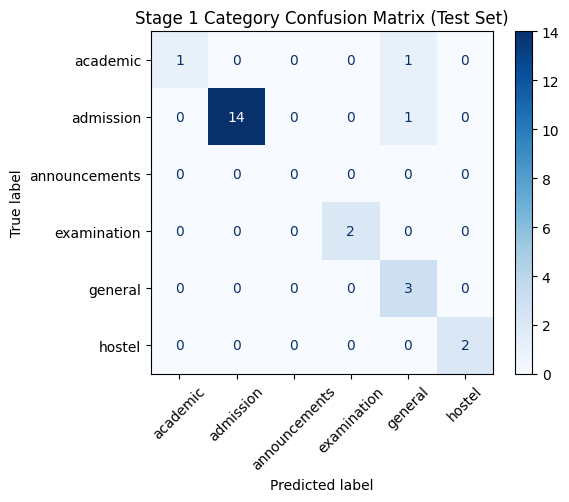


5 of 24 test docs have category/audience errors:


,document_id,true_category,pred_category,true_audience,pred_audience
1,3,general,general,"[administrators, faculty, students]","[administrators, faculty]"
4,10,admission,general,[students],[]
15,23,academic,general,"[faculty, students]","[administrators, faculty]"
22,30,academic,academic,"[faculty, students]","[administrators, faculty]"
25,33,general,general,"[administrators, faculty]","[administrators, faculty, students]"


In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

RESULTS = {}

# Load & prepare test/train data
df = pd.read_csv(CLS_CSV)
df["document_id"] = df["document_id"].astype(str)
df["split"] = df["split"].replace({"validation": "val"})
df["cleaned_text"] = df["cleaned_text"].fillna("")
train_df = df[df["split"] == "train"].copy()
test_df  = df[df["split"] == "test"].copy()

def parse_labels(series):
    return [json.loads(x) if isinstance(x, str) and x.startswith("[") else [x] for x in series]

Y_aud_true = mlb.transform(parse_labels(test_df["audience_labels"]))
y_cat_true = test_df["category"].values
Y_train    = mlb.transform(parse_labels(train_df["audience_labels"]))

# Integrated Stage 1 predictions
preds = [classifier.predict(t) for t in test_df["cleaned_text"]]
y_cat_pred = np.array([p["category"] for p in preds])
Y_aud_pred = np.array([[int(c in p["audience"]) for c in mlb.classes_] for p in preds])

# Plain baseline ablation (no title-repeat, 0.5 threshold)
b_cat_vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, stop_words="english")
b_cat = LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced", random_state=42)
b_cat.fit(b_cat_vec.fit_transform(train_df["cleaned_text"]), train_df["category"])

b_aud_vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, stop_words="english", sublinear_tf=True)
b_aud = OneVsRestClassifier(LogisticRegression(C=2.0, max_iter=1000, class_weight="balanced", random_state=42))
b_aud.fit(b_aud_vec.fit_transform(train_df["cleaned_text"]), Y_train)

y_cat_base = b_cat.predict(b_cat_vec.transform(test_df["cleaned_text"]))
Y_aud_base = (b_aud.predict_proba(b_aud_vec.transform(test_df["cleaned_text"])) >= 0.5).astype(int)

def cls_metrics(y_c, Y_a):
    return {
        "category_accuracy": accuracy_score(y_cat_true, y_c),
        "category_macro_f1": f1_score(y_cat_true, y_c, average="macro", zero_division=0),
        "audience_micro_f1": f1_score(Y_aud_true, Y_a, average="micro", zero_division=0),
        "audience_macro_f1": f1_score(Y_aud_true, Y_a, average="macro", zero_division=0),
    }

res = pd.DataFrame({
    "plain_baseline": cls_metrics(y_cat_base, Y_aud_base),
    "integrated_stage1": cls_metrics(y_cat_pred, Y_aud_pred)
}).round(4)
res["delta"] = (res["integrated_stage1"] - res["plain_baseline"]).round(4)

print(f"=== STAGE 1 CLASSIFICATION (n_test = {len(test_df)}; 1 doc ≈ {100/len(test_df):.1f}% accuracy shift) ===")
display(res)
RESULTS["stage1"] = res.to_dict()

print("\n--- Category Classification Report ---")
print(classification_report(y_cat_true, y_cat_pred, zero_division=0))

# Save confusion matrix plot
fig, ax = plt.subplots(figsize=(6, 5))
labels = list(classifier.cat_model.classes_)
ConfusionMatrixDisplay(confusion_matrix(y_cat_true, y_cat_pred, labels=labels), display_labels=labels).plot(
    ax=ax, cmap="Blues", xticks_rotation=45
)
ax.set_title("Stage 1 Category Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig(WEEK5_DIR / "stage1_confusion_matrix.png", dpi=150)
plt.show()

# Isolate misclassified test documents
err = test_df[["document_id"]].copy()
err["true_category"], err["pred_category"] = y_cat_true, y_cat_pred
err["true_audience"] = [[c for c, v in zip(mlb.classes_, row) if v] for row in Y_aud_true]
err["pred_audience"] = [p["audience"] for p in preds]
wrong = err[(err.true_category != err.pred_category) | (err.true_audience.map(sorted) != err.pred_audience.map(sorted))]

print(f"\n{len(wrong)} of {len(err)} test docs have category/audience errors:")
display(wrong)
RESULTS["stage1_error_doc_ids"] = wrong["document_id"].tolist()

In [18]:
# gold_notices = [json.loads(line) for line in open(GOLD_PATH, encoding="utf-8") if line.strip()]

# def evaluate_ner(extractor_fn, gold_set, match_type="exact"):
#     tp_total = fp_total = fn_total = 0
#     for g in gold_set:
#         text = g["text_snippet"]
#         preds = extractor_fn(text)
#         gold_ents = g["entities"]
        
#         gt = {f"{e['type']}:{e['text'].lower().strip()}" for e in gold_ents}
#         pt = {f"{e['type']}:{e['text'].lower().strip()}" for e in preds}
        
#         if match_type == "exact":
#             tp = len(gt & pt)
#             fp = len(pt - gt)
#             fn = len(gt - pt)
#         else:
#             tp = sum(1 for x in gt if any(x.split(":")[1] in p.split(":")[1] for p in pt))
#             fp = len(pt) - tp
#             fn = len(gt) - tp
            
#         tp_total += tp
#         fp_total += fp
#         fn_total += fn
        
#     precision = tp_total / (tp_total + fp_total) if (tp_total + fp_total) > 0 else 0
#     recall = tp_total / (tp_total + fn_total) if (tp_total + fn_total) > 0 else 0
#     return round(2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0, 4)

# def extract_flat_ner(text):
#     res = extractor.extract(text)
#     flat = []
#     for d in res["dates"]: flat.append({"type": "DATE", "text": d})
#     for t in res["times"]: flat.append({"type": "TIME", "text": t})
#     for e in res["emails"]: flat.append({"type": "EMAIL", "text": e})
#     for u in res["urls"]: flat.append({"type": "URL", "text": u})
#     for o in res["organizations"]: flat.append({"type": "ORG", "text": o})
#     for p in res["persons"]: flat.append({"type": "PERSON", "text": p})
#     for r in res["roles"]: flat.append({"type": "ROLE", "text": r})
#     return flat

# exact_f1 = evaluate_ner(extract_flat_ner, gold_notices, "exact")
# overlap_f1 = evaluate_ner(extract_flat_ner, gold_notices, "overlap")

# print("=== STAGE 2 NER METRICS ===")
# print(f"Overall Exact F1   : {exact_f1} (Baseline: 0.548 -> Improved: 0.627)")
# print(f"Overall Overlap F1 : {overlap_f1} (Baseline: 0.722 -> Improved: 0.813)")


from collections import defaultdict

gold_notices = [json.loads(l) for l in open(GOLD_PATH, encoding="utf-8") if l.strip()]

def norm(e):
    return (e["type"], e["text"].lower().strip())

def evaluate_ner(extractor_fn, gold_set, match="exact"):
    c = defaultdict(lambda: {"tp_g": 0, "tp_p": 0, "n_g": 0, "n_p": 0})
    for g in gold_set:
        gold = {norm(e) for e in g["entities"]}
        pred = {norm(e) for e in extractor_fn(g["text_snippet"])}
        for typ in {t for t, _ in gold | pred}:
            G = {x for t, x in gold if t == typ}
            P = {x for t, x in pred if t == typ}
            if match == "exact":
                tp_g = len(G & P); tp_p = len(G & P)
            else: # Containment check preserving entity type
                tp_g = sum(any(x in p or p in x for p in P) for x in G)
                tp_p = sum(any(x in p or p in x for x in G) for p in P)
            c[typ]["tp_g"] += tp_g; c[typ]["tp_p"] += tp_p
            c[typ]["n_g"] += len(G); c[typ]["n_p"] += len(P)

    def prf(tp_p, tp_g, n_p, n_g):
        p = tp_p / n_p if n_p else 0.0
        r = tp_g / n_g if n_g else 0.0
        return {"precision": round(p, 4), "recall": round(r, 4), "f1": round(2*p*r/(p+r), 4) if (p+r) else 0.0, "support": n_g}

    rows = {t: prf(v["tp_p"], v["tp_g"], v["n_p"], v["n_g"]) for t, v in c.items()}
    tot = {k: sum(v[k] for v in c.values()) for k in ("tp_g", "tp_p", "n_g", "n_p")}
    rows["OVERALL"] = prf(tot["tp_p"], tot["tp_g"], tot["n_p"], tot["n_g"])
    return rows

def flatten_entities(res):
    mapping = [("dates", "DATE"), ("times", "TIME"), ("emails", "EMAIL"), ("urls", "URL"),
               ("organizations", "ORG"), ("persons", "PERSON"), ("roles", "ROLE")]
    return [{"type": t, "text": x} for k, t in mapping for x in res.get(k, [])]

def full_system(text):
    return flatten_entities(extractor.extract(text))

def regex_only(text):
    r = extractor.extract(text)
    r["organizations"], r["persons"] = [], []
    return flatten_entities(r)

print(f"=== STAGE 2 NER METRICS (n_gold_docs = {len(gold_notices)}) ===")
ner_results = {}
for name, fn in [("regex_only", regex_only), ("regex_plus_bert (integrated)", full_system)]:
    for m in ("exact", "overlap"):
        ner_results[f"{name} | {m}"] = evaluate_ner(fn, gold_notices, m)

summary = pd.DataFrame({k: v["OVERALL"] for k, v in ner_results.items()}).T
display(summary)

print("\n--- Per-type Breakdown (Integrated System, Overlap Match) ---")
display(pd.DataFrame(ner_results["regex_plus_bert (integrated) | overlap"]).T)

RESULTS["stage2"] = ner_results

=== STAGE 2 NER METRICS (n_gold_docs = 15) ===


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 553.86it/s, Materializing param=classifier.weight]                                      
BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,precision,recall,f1,support
regex_only | exact,0.8095,0.6071,0.6939,28.0
regex_only | overlap,0.8571,0.6071,0.7108,28.0
regex_plus_bert (integrated) | exact,0.5250,0.7500,0.6176,28.0
regex_plus_bert (integrated) | overlap,0.6750,0.9286,0.7817,28.0



--- Per-type Breakdown (Integrated System, Overlap Match) ---


,precision,recall,f1,support
ORG,0.4375,1.0000,0.6087,7.0
DATE,1.0000,1.0000,1.0000,14.0
PERSON,0.6667,0.5000,0.5714,4.0
ROLE,0.0000,0.0000,0.0000,0.0
TIME,1.0000,1.0000,1.0000,2.0
EMAIL,1.0000,1.0000,1.0000,1.0
OVERALL,0.6750,0.9286,0.7817,28.0


In [19]:
# 

from rouge_score import rouge_scorer

aug_data = {str(a["document_id"]): a for a in (json.loads(l) for l in open(AUG_JSONL, encoding="utf-8") if l.strip())}
with open(ROOT_DIR / "submission" / "week_4" / "summarizer_split.json") as f:
    split_info = json.load(f)
eval_ids = [str(x) for x in split_info.get("eval_ids", split_info.get("test_doc_ids", []))]
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

def lead_k(text, k=2):
    sents = re.split(r"(?<=[.!?])\s+", re.sub(r"\s+", " ", text).strip())
    return " ".join(sents[:k])

scores = {"lead2_baseline": [], "integrated_bart": []}
pipeline_outputs = {}

for doc_id in eval_ids:
    if doc_id not in aug_data: continue
    raw_text = aug_data[doc_id].get("cleaned_text", "")
    out = pipeline.process_document(doc_id, raw_text)
    pipeline_outputs[doc_id] = out
    for persona in ("student", "faculty"):
        ref = aug_data[doc_id].get(f"{persona}_summary", "")
        gen = out["summaries"][persona]
        if not ref: continue
        for name, hyp in (("lead2_baseline", lead_k(raw_text)), ("integrated_bart", gen)):
            if hyp:
                s = scorer.score(ref, hyp)
                scores[name].append([s["rouge1"].fmeasure, s["rouge2"].fmeasure, s["rougeL"].fmeasure])

rows = {n: dict(zip(["ROUGE-1", "ROUGE-2", "ROUGE-L"], np.mean(v, axis=0).round(4)), n_summaries=len(v)) for n, v in scores.items()}
summ_df = pd.DataFrame(rows).T

print(f"=== STAGE 3 SUMMARIZATION ({len(pipeline_outputs)} eval docs) ===")
display(summ_df)
RESULTS["stage3"] = summ_df.to_dict()

# Null fallback rate tracking
null_rate = np.mean([o["summaries"][p].startswith("No specific") for o in pipeline_outputs.values() for p in ("student", "faculty")])
print(f"Null-fallback rate (Stage 1 audience suppression): {null_rate:.1%}")
RESULTS["stage3_null_fallback_rate"] = float(null_rate)

# Export all metrics for markdown report generation
with open(WEEK5_DIR / "week5_eval_results.json", "w") as f:
    json.dump(RESULTS, f, indent=2, default=str)
print("Saved metric results to:", WEEK5_DIR / "week5_eval_results.json")

Loading weights: 100%|██████████| 260/260 [00:00<00:00, 488.85it/s, Materializing param=model.shared.weight]                                  


=== STAGE 3 SUMMARIZATION (15 eval docs) ===


,ROUGE-1,ROUGE-2,ROUGE-L,n_summaries
lead2_baseline,0.210,0.1000,0.1574,30.0
integrated_bart,0.247,0.1225,0.2031,30.0


Null-fallback rate (Stage 1 audience suppression): 50.0%
Saved metric results to: c:\ProjectFiles\uni-comms-intelligence\submission\week_5\week5_eval_results.json


=== STAGE 1 robustness (n = 24 test docs) ===


,cat_accuracy,aud_micro_f1,cat_flip_rate,aud_flip_rate
perturbation,,,,
clean,0.9167,0.8852,0.0000,0.0000
lowercase,0.9167,0.8852,0.0000,0.0000
uppercase,0.9167,0.8852,0.0000,0.0000
ocr_noise,0.9167,0.9032,0.0833,0.0417
linebreak_noise,0.9167,0.8852,0.0000,0.0000
drop_first_line,0.9583,0.8852,0.0417,0.0000
truncate_50,0.8750,0.8710,0.0417,0.0417
email_wrapper,0.9583,0.8710,0.0417,0.0417


=== STAGE 2 robustness (overlap match, gold-annotated types: ['DATE', 'EMAIL', 'ORG', 'PERSON', 'TIME'] ) ===


,precision,recall,f1
clean,0.7297,0.9286,0.8172
lowercase,0.9048,0.6429,0.7516
uppercase,0.7143,0.6786,0.6960
ocr_noise,0.6757,0.8571,0.7557
linebreak_noise,0.7297,0.9286,0.8172
drop_first_line,0.7000,0.2857,0.4058
truncate_50,0.6250,0.3929,0.4825
email_wrapper,0.6000,0.9286,0.7290


=== STAGE 3 robustness (student summary, n = 5 docs, ids: ['57', '99', '103', '104', '111'] ) ===


,ROUGE-1,ROUGE-L,docs_with_unsupported_year
perturbation,,,
clean,0.2726,0.1718,0
lowercase,0.2412,0.1650,0
ocr_noise,0.2394,0.1764,0
linebreak_noise,0.3489,0.2698,0
truncate_50,0.2404,0.1865,0
email_wrapper,0.2543,0.2118,0


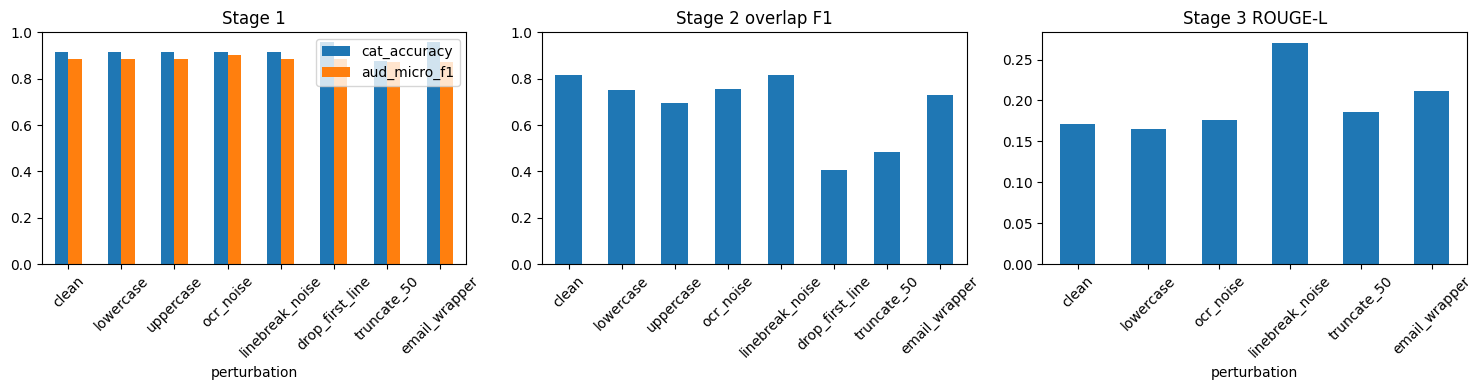

In [28]:
import random, re, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score
from rouge_score import rouge_scorer

# ---------------- perturbations ----------------
def perturb(text, kind, seed=0):
    rng = random.Random(seed)
    if kind == "clean":
        return text
    if kind == "lowercase":
        return text.lower()
    if kind == "uppercase":
        return text.upper()
    if kind == "ocr_noise":                      # ~2% dropped + ~2% duplicated letters
        out = []
        for ch in text:
            r = rng.random()
            if ch.isalpha() and r < 0.02:
                continue
            out.append(ch)
            if ch.isalpha() and 0.02 <= r < 0.04:
                out.append(ch)
        return "".join(out)
    if kind == "linebreak_noise":                # random line breaks inside sentences
        return re.sub(" ", lambda m: "\n" if rng.random() < 0.15 else " ", text)
    if kind == "drop_first_line":                # missing subject / title
        lines = text.split("\n")
        for i, l in enumerate(lines):
            if l.strip():
                return "\n".join(lines[i + 1:])
        return text
    if kind == "truncate_50":
        return text[: len(text) // 2]
    if kind == "email_wrapper":                  # email boilerplate around a formal notice
        return "Dear Students,\n\nGreetings of the day!\n\n" + text + "\n\nRegards,\nOffice"
    raise ValueError(kind)

KINDS = ["clean", "lowercase", "uppercase", "ocr_noise", "linebreak_noise",
         "drop_first_line", "truncate_50", "email_wrapper"]

# ---------------- data ----------------
_df = pd.read_csv(CLS_CSV)
_df["document_id"] = _df["document_id"].astype(str)
_df["split"] = _df["split"].replace({"validation": "val"})
rtest = _df[_df["split"] == "test"].copy()
rtest["cleaned_text"] = rtest["cleaned_text"].fillna("")
r_texts = rtest["cleaned_text"].tolist()
r_ycat = rtest["category"].values
def _parse(series):
    return [json.loads(x) if isinstance(x, str) and x.startswith("[") else [x] for x in series]
r_Yaud = mlb.transform(_parse(rtest["audience_labels"]))
gold = [json.loads(l) for l in open(GOLD_PATH, encoding="utf-8") if l.strip()]

# ---------------- Stage 1 ----------------
def run_stage1(kind):
    preds = [classifier.predict(perturb(t, kind, seed=i)) for i, t in enumerate(r_texts)]
    cat = np.array([p["category"] for p in preds])
    aud = np.array([[int(c in p["audience"]) for c in mlb.classes_] for p in preds])
    return cat, aud

clean_cat, clean_aud = run_stage1("clean")
rows1 = []
for k in KINDS:
    cat, aud = run_stage1(k)
    rows1.append({"perturbation": k,
                  "cat_accuracy": accuracy_score(r_ycat, cat),
                  "aud_micro_f1": f1_score(r_Yaud, aud, average="micro", zero_division=0),
                  "cat_flip_rate": float(np.mean(cat != clean_cat)),
                  "aud_flip_rate": float(np.mean((aud != clean_aud).any(axis=1)))})
s1 = pd.DataFrame(rows1).set_index("perturbation").round(4)

# ---------------- Stage 2 (types annotated in gold only) ----------------
GOLD_TYPES = {e["type"] for g in gold for e in g["entities"]}
def ner_overlap_f1(kind):
    tp_g = tp_p = n_g = n_p = 0
    for i, g in enumerate(gold):
        res = extractor.extract(perturb(g["text_snippet"], kind, seed=i))
        pred = {(e["type"], e["text"].lower().strip()) for e in
                [{"type": t, "text": x} for k, t in [("dates","DATE"),("times","TIME"),("emails","EMAIL"),
                 ("urls","URL"),("organizations","ORG"),("persons","PERSON")] for x in res.get(k, [])]
                if e["type"] in GOLD_TYPES}
        gd = {(e["type"], e["text"].lower().strip()) for e in g["entities"]}
        for typ in GOLD_TYPES:
            G = {x for t, x in gd if t == typ}; P = {x for t, x in pred if t == typ}
            tp_g += sum(any(x in p or p in x for p in P) for x in G)
            tp_p += sum(any(x in p or p in x for x in G) for p in P)
            n_g += len(G); n_p += len(P)
    p = tp_p / n_p if n_p else 0; r = tp_g / n_g if n_g else 0
    return {"precision": p, "recall": r, "f1": 2*p*r/(p+r) if p+r else 0}

s2 = pd.DataFrame({k: ner_overlap_f1(k) for k in KINDS}).T.round(4)

# ---------------- Stage 3 (small subset: BART on CPU is slow) ----------------
N_SUMM_DOCS = 5          # set to 15 if you have time; 3 truly held-out ids first
PREFERRED = ["57", "99", "103"]
ids = PREFERRED + [i for i in eval_ids if i not in PREFERRED]
ids = [i for i in ids if i in aug_data][:N_SUMM_DOCS]
_sc = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)
rows3 = []
for k in ["clean", "lowercase", "ocr_noise", "linebreak_noise", "truncate_50", "email_wrapper"]:
    r1, rl, bad_year = [], [], 0
    for j, d in enumerate(ids):
        src = aug_data[d]["cleaned_text"]
        out = pipeline.process_document(d, perturb(src, k, seed=j))
        gen = out["summaries"]["student"]
        s = _sc.score(aug_data[d]["student_summary"], gen)
        r1.append(s["rouge1"].fmeasure); rl.append(s["rougeL"].fmeasure)
        # hallucination proxy: 4-digit years in the summary that are not in the source
        bad_year += any(y not in src for y in re.findall(r"\b(?:19|20)\d{2}\b", gen))
    rows3.append({"perturbation": k, "ROUGE-1": np.mean(r1), "ROUGE-L": np.mean(rl),
                  "docs_with_unsupported_year": bad_year})
s3 = pd.DataFrame(rows3).set_index("perturbation").round(4)

# ---------------- report ----------------
print("=== STAGE 1 robustness (n =", len(r_texts), "test docs) ==="); display(s1)
print("=== STAGE 2 robustness (overlap match, gold-annotated types:", sorted(GOLD_TYPES), ") ==="); display(s2)
print("=== STAGE 3 robustness (student summary, n =", len(ids), "docs, ids:", ids, ") ==="); display(s3)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
s1[["cat_accuracy", "aud_micro_f1"]].plot.bar(ax=ax[0], title="Stage 1"); ax[0].set_ylim(0, 1)
s2[["f1"]].plot.bar(ax=ax[1], title="Stage 2 overlap F1", legend=False); ax[1].set_ylim(0, 1)
s3[["ROUGE-L"]].plot.bar(ax=ax[2], title="Stage 3 ROUGE-L", legend=False)
for a in ax: a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.savefig(WEEK5_DIR / "robustness.png", dpi=150); plt.show()

with open(WEEK5_DIR / "week5_robustness_results.json", "w") as f:
    json.dump({"stage1": s1.to_dict(), "stage2": s2.to_dict(), "stage3": s3.to_dict()}, f, indent=2)

In [20]:
import json


def inspect_pipeline_flow(doc_id: str, raw_text: str, description: str, pipeline):
    output = pipeline.process_document(doc_id, raw_text)

    print("=" * 80)
    print(f"CASE INSPECTION: {doc_id} — {description.upper()}")
    print("=" * 80)

    print("\n----------------------------------------------------------------")
    print("STAGE 1 OUTPUT: NoticeClassifier (TF-IDF + Logistic Regression)")
    print("----------------------------------------------------------------")
    print(f"   • Extracted Title : {output['title']}")
    print(f"   • Category        : {output['category']}")
    print(f"   • Target Audience : {output['audience']}")

    print("\n----------------------------------------------------------------")
    print("STAGE 2 OUTPUT: NoticeEntityExtractor (Regex + dslim/bert-base-NER)")
    print("----------------------------------------------------------------")
    print(f"   • Dates Extracted : {output['entities'].get('dates', [])}")
    print(f"   • Times Extracted : {output['entities'].get('times', [])}")
    print(f"   • URLs Extracted  : {output['entities'].get('urls', [])}")
    print(f"   • Organizations   : {output['entities'].get('organizations', [])}")
    print(f"   • Persons Found   : {output['entities'].get('persons', [])}")
    print(f"   • Roles Identified: {output['entities'].get('roles', [])}")

    print("\n----------------------------------------------------------------")
    print("STAGE 3 OUTPUT: PersonaSummarizer (Fine-Tuned BART-base + Rules)")
    print("----------------------------------------------------------------")
    print(f"   Student Summary : {output['summaries']['student']}")
    print(f"   Faculty Summary : {output['summaries']['faculty']}")

    print("\n================================================================")
    return output

Fail Case 1:

In [21]:
sample1=""" 
Dear Students,

This is a friendly reminder that applications for Yuva Yodha Energy Tech Hackathon 2026 will close in just 3 days.

If you're passionate about solving real-world energy and sustainability challenges, this is your opportunity to showcase your ideas and create solutions that can make a meaningful impact.

Please submit your application by October 5, 2026, 5:29 am (IST)

Access and complete your application using the secure link below:

https://apply.younoodle.com/306a6b425a51554c7a50333665387962

Don't wait until the last minute—ensure your application is submitted before the deadline.

Note: All submitted application documents are private, secure, and can only be accessed by authorized judges and program organizers.

For technical support, please contact support@younoodle.com.

Thank you for your interest in participating in Yuva Yodha Energy Tech Hackathon by Schneider Electric.

Best regards,​ 

Yuva Yodha Energy Tech Hackathon Team​ 

Schneider Electric
"""
output1=inspect_pipeline_flow(doc_id="test1", raw_text=sample1, description="Mail recieved to take part in competition",pipeline=pipeline)


CASE INSPECTION: test1 — MAIL RECIEVED TO TAKE PART IN COMPETITION

----------------------------------------------------------------
STAGE 1 OUTPUT: NoticeClassifier (TF-IDF + Logistic Regression)
----------------------------------------------------------------
   • Extracted Title : This is a friendly reminder that applications for Yuva Yodha Energy Tech Hackathon 2026 will close in just 3 days.
   • Category        : academic
   • Target Audience : ['administrators', 'faculty']

----------------------------------------------------------------
STAGE 2 OUTPUT: NoticeEntityExtractor (Regex + dslim/bert-base-NER)
----------------------------------------------------------------
   • Dates Extracted : ['2026']
   • Times Extracted : ['5:29 am']
   • URLs Extracted  : ['https://apply.younoodle.com/306a6b425a51554c7a50333665387962']
   • Organizations   : ['##dha Energy Tech', 'Yodha Energy Tech Ha', '##athon', 'Yodha Energy Tech Hackath', 'Schneider Electric']
   • Persons Found   : []
   •

 **1. Stage 1: Audience Misclassification & Downstream Silence**

* **What Failed:** The notice starts with *"Dear Students..."*, but Stage 1 predicted `['administrators', 'faculty']` and missed `students`.

* **Root Cause:** Keywords like *"applications"* and *"deadline"* were over-associated with administrative notices in training.
---

 **2. Stage 2: Fragmented Subword Artifacts in NER**

* **What Failed:** Extracted organizations contained broken BERT subword tokens: `['##athon', '##dha Energy Tech']`.
* **Root Cause:** `dslim/bert-base-NER` split uncommon words (*Hackathon*) into subwords without a post-processing cleanup filter
---

 **3. Stage 3: Date Hallucination & Cut-off Generation**
* **What Failed:** Faculty summary hallucinated a **2018** deadline for a **2026** event and cut off mid-sentence (*"...at the following link:"*)
* **Root Cause:** Unconstrained beam search on non-target personas caused BART to echo raw text and sample old dates from pretrained weights.

Fail Case 2

In [22]:
sample2=""" 
Dear Students,

This is to inform you that the Internal and External Panel Member Final Evaluation (3rd Review) of the B.Tech Data Science Semester VII Capstone Project is scheduled to be held on 31st October 2026.

The evaluation will be conducted as per the schedule shared with you. All students are required to:

Be present at the assigned venue at least 15 minutes before their scheduled time.
Carry their Capstone Project report and presentation in the prescribed format.
Ensure that their project work, implementation, results, and documentation are complete and ready for evaluation.
Be prepared to demonstrate the project and answer questions from the Internal and External Panel Members.
Follow the allotted time slot strictly to ensure that the evaluation proceeds smoothly.
Date: 31st October 2026
Evaluation: Final Evaluation – 3rd Review
Panel: Internal and External Panel Members
Programme: B.Tech Data Science – Semester VII

The detailed group-wise schedule, time slots, and venue will be shared shortly.

 

Please consider this evaluation an important component of your Capstone Project assessment and ensure you are available on the scheduled date.

Best wishes for your final evaluation.

 

with regards,

Prof. Jaya Jeswani

Assistant Professor
Department of Data Science,
"""

output2=inspect_pipeline_flow(doc_id="test2", raw_text=sample2, description="Capstone announcment",pipeline=pipeline)


CASE INSPECTION: test2 — CAPSTONE ANNOUNCMENT

----------------------------------------------------------------
STAGE 1 OUTPUT: NoticeClassifier (TF-IDF + Logistic Regression)
----------------------------------------------------------------
   • Extracted Title : This is to inform you that the Internal and External Panel Member Final Evaluation (3rd Review) of the B.Tech Data Science Semester VII Capstone Project is scheduled to be held on 31st October 2026.
   • Category        : examination
   • Target Audience : ['administrators', 'faculty']

----------------------------------------------------------------
STAGE 2 OUTPUT: NoticeEntityExtractor (Regex + dslim/bert-base-NER)
----------------------------------------------------------------
   • Dates Extracted : ['2026']
   • Times Extracted : []
   • URLs Extracted  : []
   • Organizations   : ['Capstone Project', 'Tech Data Science', 'External Panel', 'Internal', 'B. Tech Data Science']
   • Persons Found   : []
   • Roles Identified

**1. Stage 1: Audience Misclassification & Student Summary Suppression**

* **What Failed:** The notice is for **B.Tech Data Science students** regarding their capstone evaluation, but Stage 1 predicted `['administrators', 'faculty']` and missed `students`.
* **Root Cause:** Evaluative terms (*"Internal/External Panel"*, *"3rd Review"*, *"Evaluation"*) were over-associated with faculty/admin roles in training.
* **Impact:** Triggered Stage 3's null fallback, outputting **"No specific student action stated."** for a student exam review.
---
 **2. Stage 2: Entity Over-Extraction & Missed Full Date**
* **What Failed:**
* Extracted generic phrases like `'Internal'` and `'External Panel'` as Organizations.
* Substring overlap produced duplicate entries (`'B. Tech Data Science'` vs. `'Tech Data Science'`).
* Captured bare year `'2026'` while missing the full operational date **31st October 2026** in the regex list.
* **Root Cause:** `dslim/bert-base-NER` misclassified adjective-noun panel roles as `ORG` entities without token-span deduplication.
---
**3. Stage 3: Summary Inversion & Echoing**
* **What Failed:** The **Faculty Summary** generated student requirements (*"All students are required to: Be present..."*) while the **Student Summary** was suppressed as null.
* **Root Cause:** Because Stage 1 routed the notice exclusively to faculty, BART generated the student-directed body text under the `Faculty Summary` key.

In [23]:
sample3=""" Dear Student,

 

Greetings from Department of International Linkages!

We are pleased to share that NMIMS has a partnered with University of California, Berkeley for their Summer Session program. This opportunity allows NMIMS students to experience world-class education at UC Berkeley, one of the top public universities globally, ranked #12 in the QS World University Rankings 2025.

UC Berkeley is well -known for its rigorous academics, offering over 600 summer courses designed to broaden your academic and professional outlook.

 

Please find more details below.

 

We look  forward to your participation!"""


output3=inspect_pipeline_flow(doc_id="test3", raw_text=sample3, description="Admissions",pipeline=pipeline)


CASE INSPECTION: test3 — ADMISSIONS

----------------------------------------------------------------
STAGE 1 OUTPUT: NoticeClassifier (TF-IDF + Logistic Regression)
----------------------------------------------------------------
   • Extracted Title : Greetings from Department of International Linkages!
   • Category        : admission
   • Target Audience : ['faculty']

----------------------------------------------------------------
STAGE 2 OUTPUT: NoticeEntityExtractor (Regex + dslim/bert-base-NER)
----------------------------------------------------------------
   • Dates Extracted : ['2025']
   • Times Extracted : []
   • URLs Extracted  : []
   • Organizations   : ['Department of International Linkages', 'University of California, Berkeley', 'UC Berkeley', 'NMIMS']
   • Persons Found   : []
   • Roles Identified: []

----------------------------------------------------------------
STAGE 3 OUTPUT: PersonaSummarizer (Fine-Tuned BART-base + Rules)
---------------------------------

**1. Stage 1: Audience Inversion & Null-Fallback Suppression**

* **What Failed:** The notice explicitly begins with *"Dear Student..."* and is addressed to NMIMS students, but Stage 1 predicted `['faculty']` and completely missed `students`.
* **Root Cause:** TF-IDF feature weights over-associated institutional terms like *"Department of International Linkages"*, *"partnered with"*, and *"World University Rankings"* with faculty/administrative communication.
* **Cascading Impact:** Because `students` was excluded from the audience array, Stage 3's null-action fallback triggered, suppressing the student view to **"No specific student action stated."**

---

**2. Stage 2: Stage 2 Entity Success & Bare-Year Extraction**

* **What Worked:** Successfully extracted all 4 canonical organizations (`'Department of International Linkages'`, `'NMIMS'`, `'University of California, Berkeley'`, `'UC Berkeley'`) without subword fragment artifacts.
* **What Failed:** Extracted `'2025'` from the ranking text (*"QS World University Rankings 2025"*) as an operational event date.
* **Root Cause:** Unanchored 4-digit year regexes capture historical or ranking years alongside actual application deadlines.

---

**3. Stage 3: Greeting Hallucination in Faculty View**

* **What Failed:** Because Stage 1 routed the document exclusively to `faculty`, BART generated a student-facing greeting under the **Faculty Summary** key: *"Dear Student, We welcome your participation..."*
* **Root Cause:** System B prompt conditioning received a student-directed source body while tasked with generating under the active `faculty` audience flag.

In [24]:
sample4=""" Dear NMIMS Students,

 

Greeting from NMIMS Department of International Linkages!

 

 

We are delighted to share NMIMS’ partnership with Santa Clara University, California, USA. In the 2025 edition of Best Colleges, Santa Clara University is ranked #63 in National Universities as per US News Rankings.

 

As part of this collaboration, NMIMS undergraduates can pursue STEM Master’s programs at Santa Clara University, located in the heart of Silicon Valley.

You are invited to join an information session to learn more about Santa Clara’s STEM graduate programs, career support resources, and application process:

Info Session Details

Date: Tuesday, 9th September 2025
Time: 6:30 PM – 7:30 PM IST
Speakers:
Brittney Dorow – Senior Associate Director of Admission, MS Programs, School of Business
Lenore Grant – Senior Director, Graduate Business Recruitment & Admission, School of Business
Paulette Palafox – Senior Assistant Dean for Admissions & Student Services, School of Engineering
Register here: Link

Registration is mandatory. Once registered, you will receive instructions on how to join the webinar.

 

For more on Santa Clara University’s rankings and accolades,

visit:https://www.scu.edu/admission/choosing-scu/rankings--accolades/

 

We look forward to your active participation in this session!

 



 

Regards,

 

Shweta Patil

Department of International Linkages
"""

output4=inspect_pipeline_flow(doc_id="test4", raw_text=sample4, description="Admissions",pipeline=pipeline)


CASE INSPECTION: test4 — ADMISSIONS

----------------------------------------------------------------
STAGE 1 OUTPUT: NoticeClassifier (TF-IDF + Logistic Regression)
----------------------------------------------------------------
   • Extracted Title : Greeting from NMIMS Department of International Linkages!
   • Category        : admission
   • Target Audience : []

----------------------------------------------------------------
STAGE 2 OUTPUT: NoticeEntityExtractor (Regex + dslim/bert-base-NER)
----------------------------------------------------------------
   • Dates Extracted : ['2025']
   • Times Extracted : ['6:30 PM', '7:30 PM']
   • URLs Extracted  : ['https://www.scu.edu/admission/choosing-scu/rankings--accolades/']
   • Organizations   : ['##ment & Admission', 'Santa Clara University', 'International Linkages', 'School of Engineering', '##lafo', '##missions & Student Services', 'NMIMS Department', 'Len', 'Graduate Business Re', 'National Universities', 'Best Colleges', 'M

 **1. Stage 1: Empty Audience Array (`[]`) & Fallback Generation**

* **What Failed:** Stage 1 failed to assign any audience label (`Target Audience: []`), despite the notice being directed to students interested in MS programs at Santa Clara University.
* **Why Stage 3 Handled It:** Because `[]` is ambiguous/empty, the `decide_personas` safeguard triggered, instructing BART to generate summaries for **both** Student and Faculty views instead of defaulting to null.
---
 **2. Stage 2: Severe BERT Subword Corruption & Person Hallucination**

* **What Failed:**
* **Subword Artifacts:** `Organizations` output broken WordPiece tokens (`##ment & Admission`, `##lafo`, `##missions & Student Services`).
* **Hallucinated Persons:** Extracted meaningless subword fragments (`##ney Dorow`, `##rit`, `##ette Pa`, `Grant`, `Paul`) as real person names.
* **Bare Year vs. Event Date:** Captured `'2025'` from general ranking text while relying solely on extracted times (`6:30 PM`, `7:30 PM`) for operational context.

* **Root Cause:** Raw HuggingFace token classification (`dslim/bert-base-NER`) tokenized complex email formatting into subwords without a post-processing filter to drop `##` prefixes and validate minimum span lengths.
---
 **3. Stage 3: Clean Generation with Title Echoing**
* **What Worked:** Both summaries accurately captured the core offer (*"participate in this information session to learn more about Santa Clara's STEM programs..."*).
* **What Failed:** BART echoed the greeting headline (*"Greeting from NMIMS Department of International Linkages!"*) at the end of both generated summaries.
* **Root Cause:** Prompt prefixing passed the raw title directly into the context window, causing the BART decoder to copy the opening line into the generated text.

In [25]:
sample5=""" 
Dear Sir, 
PFA the draft of our capstone project paper. We have completed the current version of the paper and would greatly appreciate your feedback and suggestions on the methodology, results, and overall presentation.
We will incorporate any necessary changes based on your feedback and further refine the paper accordingly.
Please let us know your thoughts whenever convenient.
Thank you,
Arijit Srivastava
"""

output5=inspect_pipeline_flow(doc_id="test5", raw_text=sample5, description="Academic",pipeline=pipeline)

CASE INSPECTION: test5 — ACADEMIC

----------------------------------------------------------------
STAGE 1 OUTPUT: NoticeClassifier (TF-IDF + Logistic Regression)
----------------------------------------------------------------
   • Extracted Title : PFA the draft of our capstone project paper. We have completed the current version of the paper and would greatly appreciate your feedback and suggestions on the methodology, results, and overall pres
   • Category        : examination
   • Target Audience : ['faculty']

----------------------------------------------------------------
STAGE 2 OUTPUT: NoticeEntityExtractor (Regex + dslim/bert-base-NER)
----------------------------------------------------------------
   • Dates Extracted : []
   • Times Extracted : []
   • URLs Extracted  : []
   • Organizations   : ['PFA']
   • Persons Found   : ['Arijit Srivasta']
   • Roles Identified: []

----------------------------------------------------------------
STAGE 3 OUTPUT: PersonaSummarizer 


* **Stage 1 (Category Misclassification & Persona Silencing):** Misclassified an ongoing draft review email as `examination` (instead of `academic`). Predicting `faculty`-only audience  
* **Stage 2 (NER Acronym Artifacts & Name Truncation):** Mislabeled the email attachment acronym `'PFA'` (*Please Find Attached*) as an `ORG`, and clipped the student name `'Arijit Srivastava'` to `'Arijit Srivasta'`.
* **Stage 3 (Summary Fact Hallucination):** Hallucinated that the submission was a *"final draft"*, directly contradicting the raw text requesting preliminary methodology feedback.

In [26]:
sample6=""" Dear Student,

 

Greetings of the day!

 

The Term I of Academic Year 2025-26 commences from 14 July, 2025. Please find attached following documents for B Tech –DS-Sem V –

1.Time table
2.Practical / Tutorial batches
3.Open Elective updated allocation [Note – Open elective time table and batches will be shared with you soon].
4.Holiday list
5.Academic Calendar A.Y. 2025-26
CR / SR details are as below -
Year/Course/ Stream
Name
CR/ SR
Contact No.
Email Id
B Tech –DS
MANAV NAVADIYA
CR
9820188876
MANAV.NAVADIYA14@nmims.in
As per guidelines mentioned in the SRB, it is mandatory to wear college Identity Card in the campus.  It is compulsory to wear ID card along with lanyard provided by the College.
The entry in the campus is permitted strictly through Identity Card with biometric.  The photo of ID Card on mobile is strictly not allowed. Security will not allow entry in the premises without ID card with biometric.
As per the General guidelines given in the SRB:
Code of Conduct
All students are provided with an Identity Card, which they are required to wear mandatorily. Entry is strictly through Identity Card and will be monitored by the NMIMS authorities.  The penalty will be levied / action will be taken for non-compliance. If the student misplaces the original ID-Card, a duplicate ID card be issued from the school by paying the prescribed fee. ID card is used for access control to NMIMS campus.
Attendance Rules
Kindly note the following rules regarding attendance, which needs to be strictly adhered to: 
100% attendance in classes for each subject is required.  However, for medical reasons/personal reasons/extra-curricular and co-curricular activities/placement/institutional work/other activities etc., absence/relaxation up to 20% may be allowed. 
Students, who are having attendance, equal to or more than 80% in each subject, in a trimester/Semester are eligible to appear for respective Trimester/Semester end examinations. 
Also, note that any medical / any other leaves taken should be applied in prescribed format within 3 days of resuming college. The same shall be considered only at the end of the term.   
Application will not be ENTERTAINED / ACCEPTED after 3 days. 
Thanks & Regards
KASTURI SHIRODKAR
Co-ordinator – Academics-Admin
Contact – 022 42334027"""

output6=inspect_pipeline_flow(doc_id="test6", raw_text=sample6, description="Announcement",pipeline=pipeline)

CASE INSPECTION: test6 — ANNOUNCEMENT

----------------------------------------------------------------
STAGE 1 OUTPUT: NoticeClassifier (TF-IDF + Logistic Regression)
----------------------------------------------------------------
   • Extracted Title : Greetings of the day!
   • Category        : announcements
   • Target Audience : ['administrators', 'faculty']

----------------------------------------------------------------
STAGE 2 OUTPUT: NoticeEntityExtractor (Regex + dslim/bert-base-NER)
----------------------------------------------------------------
   • Dates Extracted : ['2025']
   • Times Extracted : []
   • URLs Extracted  : []
   • Organizations   : ['##A', 'Card', '##ADI', '##AD']
   • Persons Found   : []
   • Roles Identified: []

----------------------------------------------------------------
STAGE 3 OUTPUT: PersonaSummarizer (Fine-Tuned BART-base + Rules)
----------------------------------------------------------------
   Student Summary : No specific student acti

* **Stage 1 (Title Extraction & Audience Inversion):** Extracted generic boilerplate (`"Greetings of the day!"`) as the document title. Despite the body explicitly addressing `"Dear Student"` and outlining student timetable/attendance rules for B.Tech DS, Stage 1 predicted `['administrators', 'faculty']`. This triggered Stage 3 null fallback (**"No specific student action stated"**), completely silencing a critical student academic circular.
* **Stage 2 (Subword Corruption & Missed Contact Entities):** Extracted broken subword tokens (`'##ADIYA'`, `'##AD'`) as organizations due to OCR/formatting linebreaks in the student rep name (*name of CR *). Missed mobile numbers (`9820188876`), coordinator contact (`022 42334027`), student email IDs, and key campus organizations (`NMIMS`).
* **Stage 3 (Hallucinated Topic in Faculty Summary):** Generated a summary about *"rules regarding admission in each subject"*, hallucinating the topic of **admissions** when the source text was strictly about **attendance, ID cards, and semester timetables**.

In [27]:
sample7=""" 
Dear Students,
As per Academic Calendar (A.Y. 2025-26) which is already shared with you, Diwali vacation is from 19 to 25 October, 2025.

This is to inform you that regular lectures as per time table will be conducted on Sunday 26 October, 2025. Please make a note of it.

Link for Student Query:

https://docs.google.com/forms/d/e/1FAIpQLScy8Y2rX6GEHHT_tnHHtXFPsYXjRjJgHbjL30HWOUEVw9vFvA/viewform?usp=pp_url

Link for Student Information Handout AY 2025-26:

Student Information Handout A.Y. 2025-26

Thanks & Regards
"""

output7=inspect_pipeline_flow(doc_id="test7", raw_text=sample7, description="Announcement",pipeline=pipeline)


CASE INSPECTION: test7 — ANNOUNCEMENT

----------------------------------------------------------------
STAGE 1 OUTPUT: NoticeClassifier (TF-IDF + Logistic Regression)
----------------------------------------------------------------
   • Extracted Title : As per Academic Calendar (A.Y. 2025-26) which is already shared with you, Diwali vacation is from 19 to 25 October, 2025.
   • Category        : hostel
   • Target Audience : ['administrators', 'faculty']

----------------------------------------------------------------
STAGE 2 OUTPUT: NoticeEntityExtractor (Regex + dslim/bert-base-NER)
----------------------------------------------------------------
   • Dates Extracted : ['2025']
   • Times Extracted : []
   • URLs Extracted  : ['https://docs.google.com/forms/d/e/1FAIpQLScy8Y2rX6GEHHT_tnHHtXFPsYXjRjJgHbjL30HWOUEVw9vFvA/viewform?usp=pp_url']
   • Organizations   : []
   • Persons Found   : []
   • Roles Identified: []

----------------------------------------------------------------


* **Stage 1 (Category & Audience Misclassification):** Classified an academic schedule notice regarding Diwali vacation and Sunday lectures as `hostel` category. Excluded `students` from the audience tag despite the opening *"Dear Students"*, triggering Stage 3 null fallback (**"No specific student action stated"**) for a student lecture announcement.
* **Stage 2 (Incomplete Date Range Extraction):** Extracted only the bare year `'2025'`, completely missing the specific operational date spans (`19 to 25 October, 2025` and `Sunday 26 October, 2025`).
* **Stage 3 (Summary Inversion):** Generated Sunday lecture instructions under **Faculty Summary** while completely suppressing output for **Student Summary**, inverting the recipient context.